# Task 3: Correlation Between News Sentiment and Stock Movement

This notebook builds a sentiment-to-returns pipeline:

- Score headline sentiment with VADER
- Align news dates to trading days
- Compute daily stock returns
- Correlate daily sentiment with returns and visualize results

## 1) Imports and Setup
If `nltk` or `yfinance` are missing, install them in your environment before running this notebook.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yfinance as yf
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [5]:
nltk.download("vader_lexicon", quiet=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2) Load and Prepare News Data

In [6]:
data_path = Path("..") / "data" / "raw" / "raw_analyst_ratings.csv"
news_df = pd.read_csv(data_path)

news_df["date"] = pd.to_datetime(news_df["date"], format="mixed", utc=True)
news_df["stock"] = news_df["stock"].str.upper().str.strip()

# Normalize to UTC date (floor to midnight) for alignment
news_df["pub_date"] = news_df["date"].dt.tz_convert("UTC").dt.floor("D").dt.tz_localize(None)

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock,pub_date
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,2020-06-05
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,2020-06-03
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,2020-05-26
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,2020-05-22
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,2020-05-22


## 3) Sentiment Scoring (VADER)

In [7]:
sia = SentimentIntensityAnalyzer()

# VADER compound score in [-1, 1]
news_df["sentiment"] = news_df["headline"].fillna("").apply(lambda x: sia.polarity_scores(x)["compound"])

news_df[["headline", "sentiment"]].head()

,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


## 4) Download Prices and Compute Returns
To keep the notebook fast, use the top N most-covered stocks. Increase `top_n_stocks` to include more.

In [8]:
top_n_stocks = 5
top_stocks = news_df["stock"].value_counts().head(top_n_stocks).index.tolist()
top_stocks

['MRK', 'MS', 'NVDA', 'MU', 'QQQ']

In [10]:
def load_price_data(ticker, start_date, end_date):
    price_df = yf.Ticker(ticker).history(
        start=start_date, end=end_date, auto_adjust=False
    )
    if price_df is None or price_df.empty:
        return pd.DataFrame(columns=["trade_date", "Close", "Adj Close", "return_pct"])
    
    price_df = price_df.reset_index()
    if "Date" in price_df.columns:
        price_df = price_df.rename(columns={"Date": "trade_date"})
    elif "Datetime" in price_df.columns:
        price_df = price_df.rename(columns={"Datetime": "trade_date"})
    
    price_df["trade_date"] = pd.to_datetime(price_df["trade_date"]).dt.tz_localize(None)
    close_col = "Adj Close" if "Adj Close" in price_df.columns else "Close"
    price_df["return_pct"] = price_df[close_col].pct_change() * 100
    return price_df

min_date = news_df["pub_date"].min() - pd.Timedelta(days=1)
max_date = news_df["pub_date"].max() + pd.Timedelta(days=1)

price_data = {}
for ticker in top_stocks:
    price_data[ticker] = load_price_data(ticker, min_date, max_date)

price_data[top_stocks[0]].head()

,trade_date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,return_pct
0,2009-02-13,27.929390,28.053434,27.213739,27.433207,15.078454,11000751,0.0,0.0,NaN
1,2009-02-17,26.851145,27.700382,26.603052,27.299618,15.005028,21584922,0.0,0.0,-0.486961
2,2009-02-18,27.395039,27.480915,26.717558,27.328243,15.020765,15041210,0.0,0.0,0.104882
3,2009-02-19,27.604961,27.671757,27.156488,27.223282,14.963071,10332651,0.0,0.0,-0.384098
4,2009-02-20,26.812977,27.213739,26.517176,26.812977,14.737556,18552639,0.0,0.0,-1.507146


## 5) Align News to Trading Days and Aggregate Daily Sentiment

In [19]:
merged_all = []
for ticker in top_stocks:
    news_stock = news_df[news_df["stock"] == ticker].copy()
    news_stock["pub_date"] = pd.to_datetime(news_stock["pub_date"]).astype("datetime64[ns]")

    price_df = price_data[ticker].copy()
    if price_df.empty:
        continue
    close_col = "Adj Close" if "Adj Close" in price_df.columns else "Close"
    price_df = price_df[["trade_date", close_col, "return_pct"]].copy()
    if close_col != "Adj Close":
        price_df = price_df.rename(columns={close_col: "Adj Close"})
    price_df["trade_date"] = pd.to_datetime(price_df["trade_date"]).astype("datetime64[ns]")

    # Align each news item to the next trading day (weekends/holidays)
    merged = pd.merge_asof(
        news_stock.sort_values("pub_date"),
        price_df.sort_values("trade_date"),
        left_on="pub_date",
        right_on="trade_date",
        direction="forward",
    )
    merged["ticker"] = ticker
    merged_all.append(merged)

aligned_df = pd.concat(merged_all, ignore_index=True)
merged_df = aligned_df
aligned_df.head()

,Unnamed: 0,headline,url,publisher,date,stock,pub_date,sentiment,trade_date,Adj Close,return_pct,ticker
0,854073,Wall Street News Alert: Stocks This Morning: G...,https://www.benzinga.com/09/07/245/wall-street...,Benzinga Staff,2009-07-27 00:00:00+00:00,MRK,2009-07-27,0.5106,2009-07-27,16.637545,-0.709862,MRK
1,854072,ParagonReport.com Complimentary Market Update ...,https://www.benzinga.com/09/08/675/paragonrepo...,Benzinga Staff,2009-08-07 00:00:00+00:00,MRK,2009-08-07,0.4404,2009-08-07,16.275265,2.520435,MRK
2,854071,ParagonReport.com Complimentary Market Update ...,https://www.benzinga.com/09/08/1612/paragonrep...,Benzinga Staff,2009-08-10 00:00:00+00:00,MRK,2009-08-10,0.7964,2009-08-10,16.545618,1.661130,MRK
3,854068,Sanofi-aventis (SNY) Completes Acquisition of ...,https://www.benzinga.com/benzingastaff1/2009/9...,BenzingaStaff1,2009-09-18 00:00:00+00:00,MRK,2009-09-18,0.0000,2009-09-18,17.446266,-0.406123,MRK
4,854066,Merck Says It Won't Seek Another Larger Merger,https://www.benzinga.com/markets/company-news/...,Benzinga Staff,2009-11-04 00:00:00+00:00,MRK,2009-11-04,0.0000,2009-11-04,17.862177,6.423255,MRK


In [15]:
daily = (
    aligned_df.groupby(["stock", "trade_date"])
    .agg(avg_sentiment=("sentiment", "mean"), avg_return=("return_pct", "mean"), article_count=("headline", "count"))
    .reset_index()
 )
daily.head()

,stock,trade_date,avg_sentiment,avg_return,article_count
0,MRK,2009-07-27,0.5106,-0.709862,1
1,MRK,2009-08-07,0.4404,2.520435,1
2,MRK,2009-08-10,0.7964,1.661130,1
3,MRK,2009-09-18,0.0000,-0.406123,1
4,MRK,2009-11-04,0.1480,6.423255,2


## 6) Correlation Analysis

In [20]:
# Overall Pearson correlation
corr_value = daily[["avg_sentiment", "avg_return"]].corr(method="pearson").iloc[0, 1]
print(f"Overall Pearson correlation (sentiment vs return): {corr_value:.4f}")

# Per-stock correlation
per_stock_corr = (
    daily.groupby("stock")[["avg_sentiment", "avg_return"]]
    .corr(method="pearson")
    .unstack().iloc[:, 1]
    .reset_index()
    .rename(columns={"avg_return": "corr_sentiment_return"})
 )
per_stock_corr

Overall Pearson correlation (sentiment vs return): 0.1558


,stock,avg_sentiment
,,corr_sentiment_return
0,MRK,0.063508
1,MS,0.106766
2,MU,0.255493
3,NVDA,0.207497
4,QQQ,0.078469


## 7) Visualizations

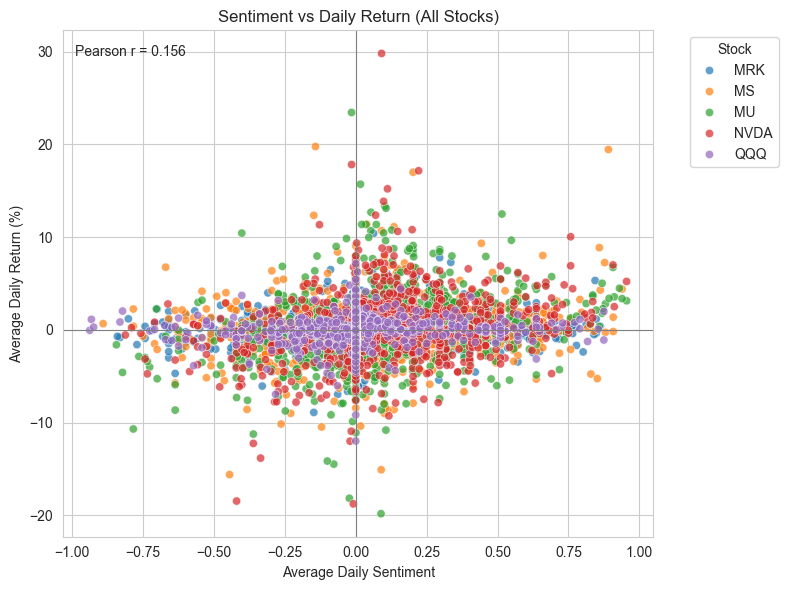

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=daily, x="avg_sentiment", y="avg_return", hue="stock", alpha=0.7)
plt.title("Sentiment vs Daily Return (All Stocks)")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Average Daily Return (%)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.text(0.02, 0.95, f"Pearson r = {corr_value:.3f}", transform=plt.gca().transAxes)
plt.legend(title="Stock", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

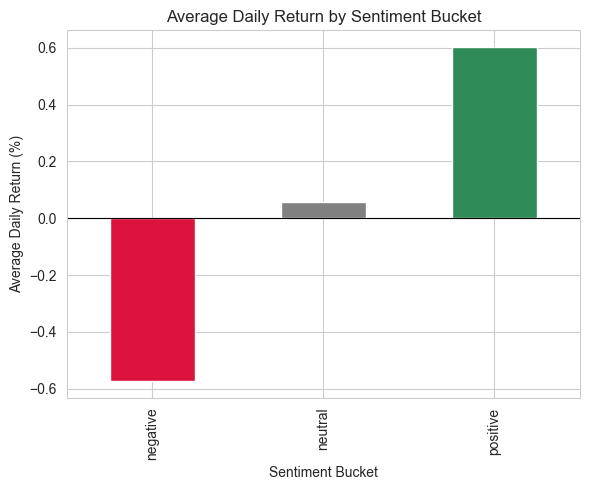

In [21]:
# Classify days by sentiment
def sentiment_bucket(x):
    if x >= 0.05:
        return "positive"
    if x <= -0.05:
        return "negative"
    return "neutral"

daily["sentiment_bucket"] = daily["avg_sentiment"].apply(sentiment_bucket)

bucket_returns = daily.groupby("sentiment_bucket")["avg_return"].mean().reindex(["negative", "neutral", "positive"])

plt.figure(figsize=(6, 5))
bucket_returns.plot(kind="bar", color=["crimson", "gray", "seagreen"])
plt.title("Average Daily Return by Sentiment Bucket")
plt.xlabel("Sentiment Bucket")
plt.ylabel("Average Daily Return (%)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 8) Interpretation and Limitations
- Correlation values quantify association, not causation.
- Results may be sensitive to the sentiment tool, alignment choice (next trading day), and stock universe size.
- Consider lag effects (e.g., +1 or +2 days), volume-weighted returns, or intraday data for deeper analysis.